# Analisi Report delle comunita'

In [1]:
#Libreria da Aggiungere
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import ipywidgets as widgets
from IPython.display import clear_output, display
import seaborn as sns

In [ ]:
# Inizializzazione delle strutture dati
data_nodi = []
nodi_isolati_count = 0
current_community = None
in_table = False
file="/content/sample_data/report.txt"
# Caricamento del file 'report.txt'
try:
    with open(file, "r", encoding="utf-8") as f:
        lines = f.readlines()
except FileNotFoundError:
    print(
        "Errore: Carica il file del report su Colab e nominalo 'report.txt' prima di eseguire."
    )
    lines = []

# Parsing avanzato del testo
for line in lines:
    line_str = line.strip()

    # Rilevamento delle righe con NaN o esplicitamente isolate
    if "NaN" in line_str or "isolat" in line_str.lower():
        parts = re.split(r"\s{2,}", line_str)
        if len(parts) >= 2 and "NaN" in line_str:
            nodi_isolati_count += 1
            continue
        elif "NaN" in line_str:
            nodi_isolati_count += line_str.count("NaN") // 2 or 1
            continue

    # Identifica la comunità corrente
    if line_str.startswith("COMUNITÀ:"):
        current_community = line_str.split(":")[1].strip()
        in_table = False
        continue

    # Riconosce l'inizio della tabella dei dettagli dei nodi
    if "Grado Interno (k_in)" in line_str:
        in_table = True
        continue

    # Interrompe la lettura dei nodi se finisce la sezione
    if in_table and (line_str.startswith("====") or line_str == ""):
        in_table = False
        continue

    # Estrae i dati dei nodi validi appartenenti alle comunità
    if in_table and current_community and not line_str.startswith("---"):
        parts = re.split(r"\s{2,}", line_str)
        if len(parts) >= 4:
            try:
                nodo = parts[0]
                k_in = int(parts[1])
                k_out = int(parts[2])
                condizione = parts[3]
                data_nodi.append(
                    {
                        "Comunità": current_community,
                        "Nodo": nodo,
                        "k_in": k_in,
                        "k_out": k_out,
                        "Soddisfatta": 1 if "NON" not in condizione else 0,
                    }
                )
            except ValueError:
                continue

# Creazione del DataFrame globale accessibile dalle celle successive
df = pd.DataFrame(data_nodi)

# Stampa del resoconto
print("=" * 60)
print("               ANALISI DEL RETICOLO E COMUNITÀ              ")
print("=" * 60)
print(f"• Nodi totali inseriti in comunità: {len(df)}")
print(
    f"• Nodi ISOLATI (NaN / nessuna comunità): {nodi_isolati_count} ➔ (Nodi senza legami strutturati)"
)
if not df.empty:
    print(f"• Numero totale di comunità rilevate: {df['Comunità'].nunique()}")
    soddisfatti = df["Soddisfatta"].sum()
    non_soddisfatti = len(df) - soddisfatti
    print(f"• Nodi che SODDISFANO la condizione (k_in > k_out): {soddisfatti}")
    print(f"• Nodi che NON SODDISFANO la condizione: {non_soddisfatti}")
print("=" * 60)


               ANALISI DEL RETICOLO E COMUNITÀ              
• Nodi totali inseriti in comunità: 52204
• Nodi ISOLATI (NaN / nessuna comunità): 0 ➔ (Nodi senza legami strutturati)
• Numero totale di comunità rilevate: 62
• Nodi che SODDISFANO la condizione (k_in > k_out): 43170
• Nodi che NON SODDISFANO la condizione: 9034


COMUNITÀ                       | NUMERO ESATTO DI NODI
--------------------------------------------------
60.0                           | 3180                
19.0                           | 2060                
53.0                           | 2024                
41.0                           | 2020                
37.0                           | 1959                
29.0                           | 1756                
46.0                           | 1719                
12.0                           | 1686                
59.0                           | 1663                
30.0                           | 1619                
32.0                           | 1539                
57.0                           | 1499                
10.0                           | 1443                
22.0                           | 1417                
26.0                           | 1266                
13.0                           | 1264                
35.0                          

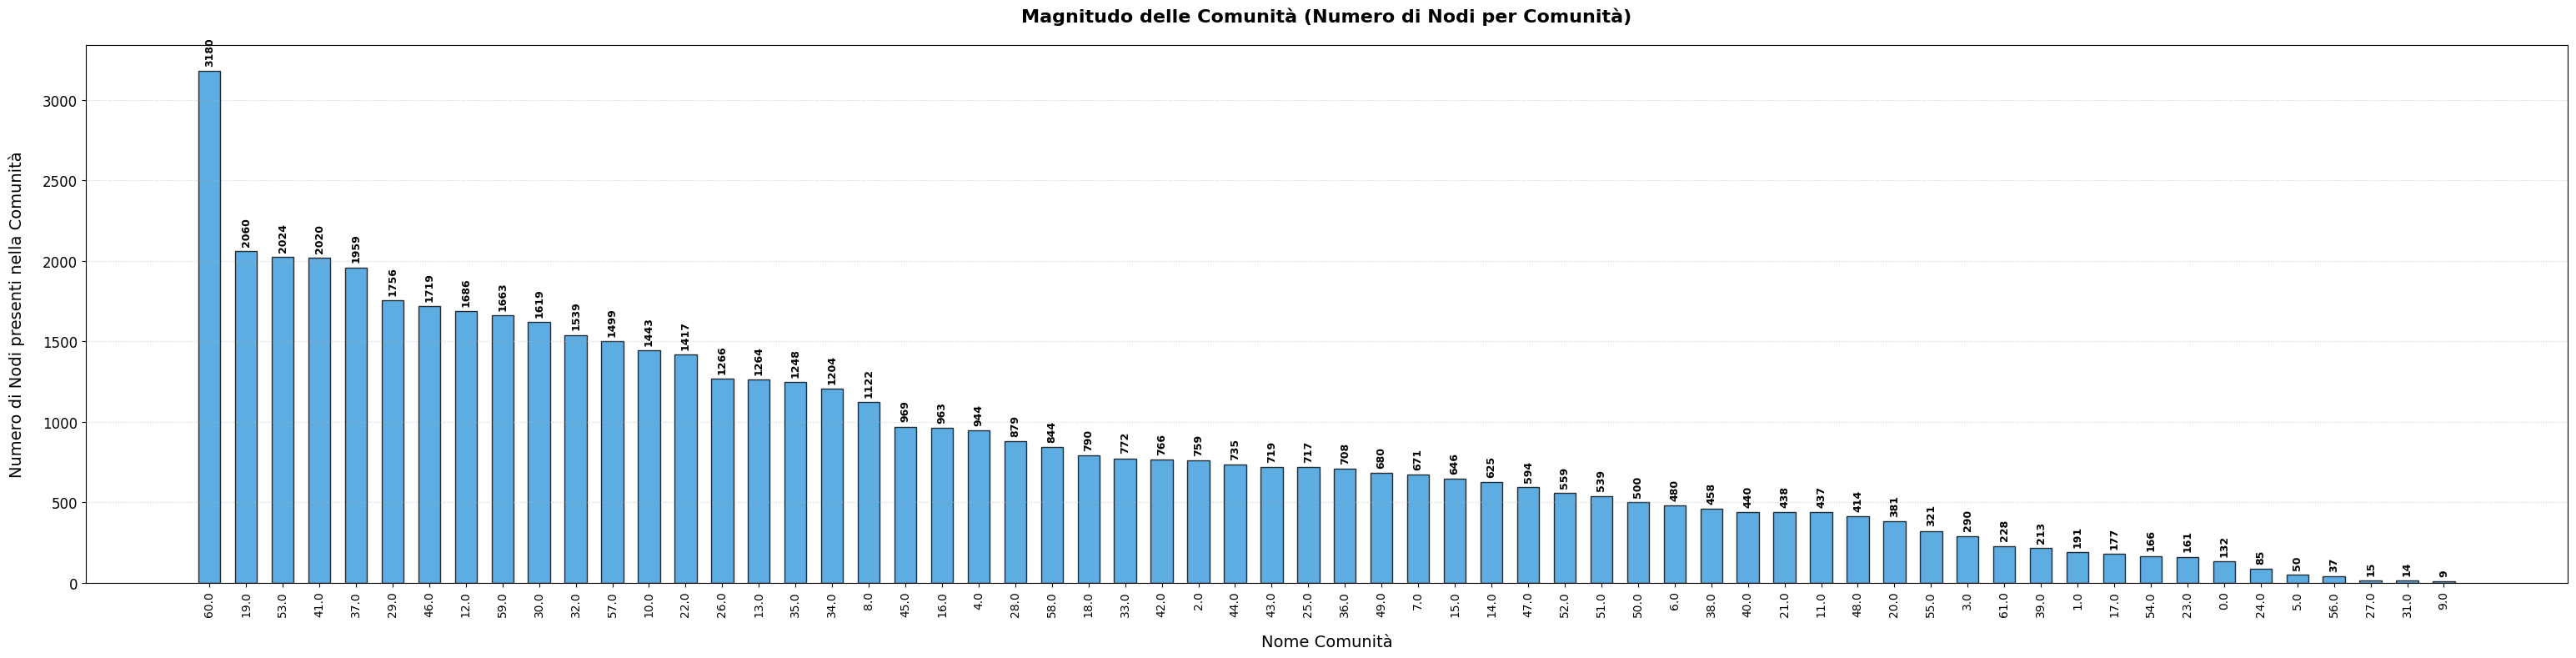

In [ ]:
if not df.empty:
    # 1. Calcolo esatto del numero di nodi per ciascuna comunità
    community_sizes = df["Comunità"].value_counts().sort_values(ascending=False)
    num_communities = len(community_sizes)

    # 2. STAMPA DELLA TABELLA DETTAGLIATA (Per una precisione assoluta)
    print("=" * 50)
    print(f"{'COMUNITÀ':<30} | {'NUMERO ESATTO DI NODI':<20}")
    print("-" * 50)
    for com, size in community_sizes.items():
        print(f"{com:<30} | {size:<20}")
    print("=" * 50)
    print("\n" + ("*" * 80) + "\n")

    # 3. GENERAZIONE DEL GRAFICO ESPANSO
    dynamic_width = max(12, min(50, num_communities * 0.5))
    plt.figure(figsize=(dynamic_width, 8))

    bars = plt.bar(
        community_sizes.index,
        community_sizes.values,
        color="#3498db",
        edgecolor="black",
        alpha=0.8,
        width=0.6,
    )

    plt.title(
        "Magnitudo delle Comunità (Numero di Nodi per Comunità)",
        fontsize=16,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel("Nome Comunità", fontsize=14, labelpad=15)
    plt.ylabel("Numero di Nodi presenti nella Comunità", fontsize=14, labelpad=15)

    plt.xticks(rotation=90, ha="center", fontsize=10)
    plt.yticks(fontsize=12)
    plt.grid(axis="y", linestyle=":", alpha=0.6)

    # Mostra il valore anche al vertice di ogni barra (ruotato a 90° se sono troppe per non sovrapporsi)
    rot_angle = 90 if num_communities > 20 else 0
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + (max(community_sizes.values) * 0.01),
            f"{int(yval)}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=9,
            rotation=rot_angle,
        )

    plt.tight_layout()
    plt.show()
else:
    print("Nessun dato disponibile per generare il grafico.")

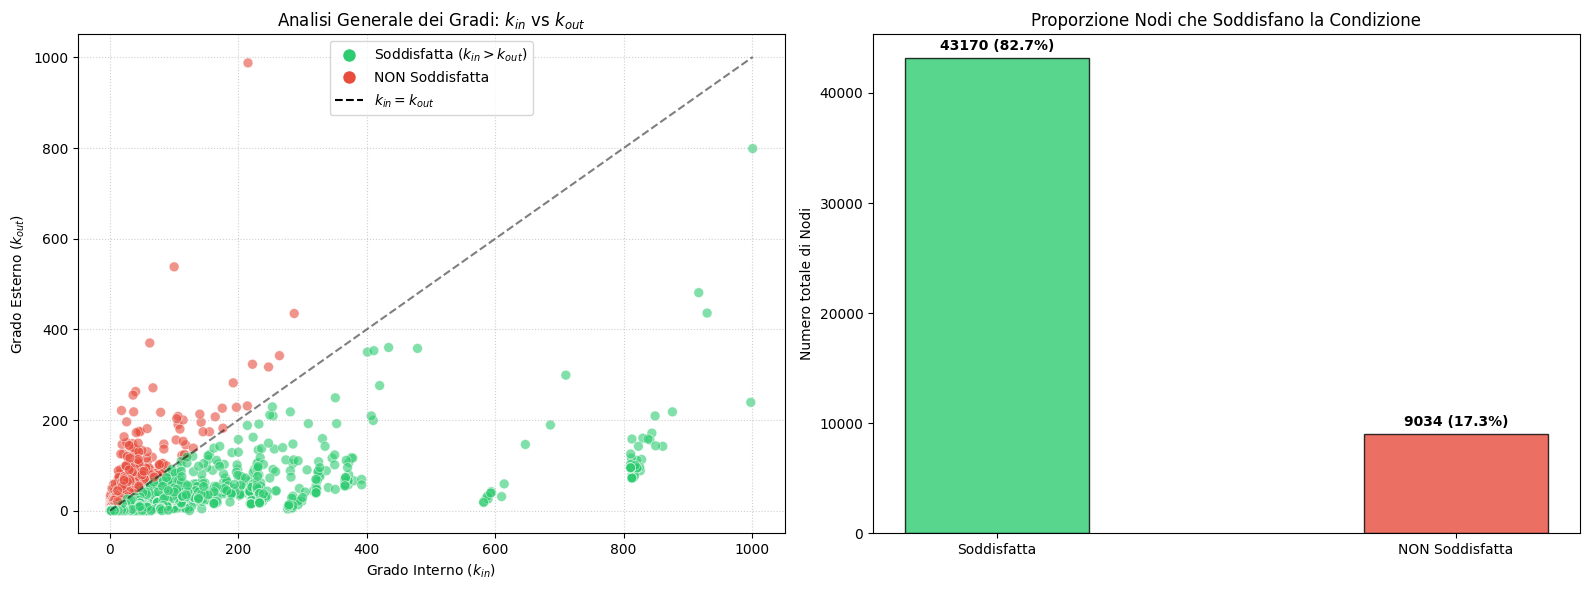

In [ ]:
if not df.empty:
    from matplotlib.lines import Line2D

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Scatter Plot Grado Interno vs Esterno
    colors = df["Soddisfatta"].map({1: "#2ecc71", 0: "#e74c3c"})
    ax1.scatter(
        df["k_in"],
        df["k_out"],
        c=colors,
        alpha=0.6,
        edgecolors="w",
        linewidth=0.5,
        s=50,
    )

    # Linea bisettrice di confine k_in = k_out
    max_val = max(df["k_in"].max(), df["k_out"].max())
    ax1.plot([0, max_val], [0, max_val], "k--", alpha=0.5)

    ax1.set_title("Analisi Generale dei Gradi: $k_{in}$ vs $k_{out}$", fontsize=12)
    ax1.set_xlabel("Grado Interno ($k_{in}$)")
    ax1.set_ylabel("Grado Esterno ($k_{out}$)")
    ax1.grid(True, linestyle=":", alpha=0.6)

    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Soddisfatta ($k_{in} > k_{out}$)",
            markerfacecolor="#2ecc71",
            markersize=10,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="NON Soddisfatta",
            markerfacecolor="#e74c3c",
            markersize=10,
        ),
        Line2D([0], [0], color="k", linestyle="--", label="$k_{in} = k_{out}$"),
    ]
    ax1.legend(handles=legend_elements)

    # 2. Bar Plot Soddisfatti vs Non Soddisfatti
    soddisfatti = df["Soddisfatta"].sum()
    non_soddisfatti = len(df) - soddisfatti

    bars = ax2.bar(
        ["Soddisfatta", "NON Soddisfatta"],
        [soddisfatti, non_soddisfatti],
        color=["#2ecc71", "#e74c3c"],
        edgecolor="black",
        alpha=0.8,
        width=0.4,
    )
    ax2.set_title("Proporzione Nodi che Soddisfano la Condizione", fontsize=12)
    ax2.set_ylabel("Numero totale di Nodi")

    for bar in bars:
        yval = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            yval + (max(soddisfatti, non_soddisfatti) * 0.01),
            f"{yval} ({yval/len(df)*100:.1f}%)",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()
else:
    print("Nessun dato disponibile per generare i grafici.")

interactive(children=(Dropdown(description='Comunità:', options=('0.0', '1.0', '10.0', '11.0', '12.0', '13.0',…

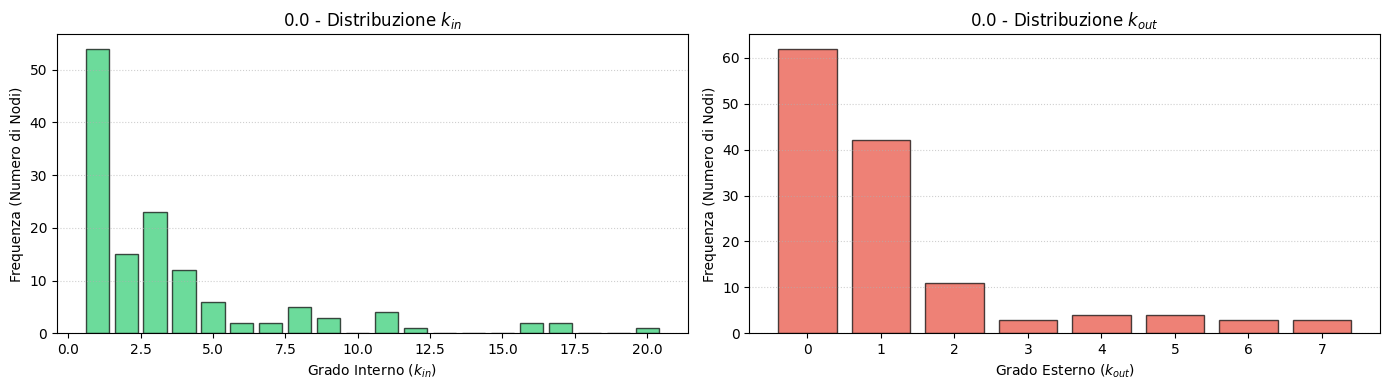

Output()

In [ ]:
# Creiamo un'area dedicata all'output per evitare che Colab si perda i grafici
output_area = widgets.Output()


# Funzione di analisi (uguale a prima, ma scrive dentro l'area dedicata)
def analizza_comunita(com_name):
    with output_area:
        output_area.clear_output(wait=True)

        com_data = df[df["Comunità"] == com_name]
        num_nodi = len(com_data)
        num_archi_interni = int(np.ceil(com_data["k_in"].sum() / 2))

        nodi_non_soddisfatti = com_data[com_data["Soddisfatta"] == 0][
            "Nodo"
        ].tolist()
        is_forte = len(nodi_non_soddisfatti) == 0

        stato_comunita = (
            "🟢 FORTE (Tutti i nodi soddisfano k_in > k_out)"
            if is_forte
            else "🔴 DEBOLE / NON PURA (Alcuni nodi violano la proprietà)"
        )

        print("=" * 80)
        print(f"📊 ANALISI DETTAGLIATA COMUNITÀ: {com_name}")
        print("=" * 80)
        print(f"  • Numero di nodi: {num_nodi}")
        print(f"  • Numero di archi interni stimati: {num_archi_interni}")
        print(f"  • Status strutturale: {stato_comunita}")

        if not is_forte:
            print(
                f"  • Nodi che NON soddisfano la proprietà ({len(nodi_non_soddisfatti)}): {', '.join(map(str, nodi_non_soddisfatti))}"
            )
        else:
            print("  • Nodi che NON soddisfano la proprietà: Nessuno! Eccellente.")

        print("-" * 80)

        # Grafici
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        bins_in = (
            np.arange(com_data["k_in"].min(), com_data["k_in"].max() + 2) - 0.5
        )
        ax1.hist(
            com_data["k_in"],
            bins=bins_in,
            color="#2ecc71",
            edgecolor="black",
            alpha=0.7,
            rwidth=0.8,
        )
        ax1.set_title(f"{com_name} - Distribuzione $k_{{in}}$")
        ax1.set_xlabel("Grado Interno ($k_{in}$)")
        ax1.set_ylabel("Frequenza (Numero di Nodi)")
        ax1.grid(axis="y", linestyle=":", alpha=0.6)

        bins_out = (
            np.arange(com_data["k_out"].min(), com_data["k_out"].max() + 2) - 0.5
        )
        ax2.hist(
            com_data["k_out"],
            bins=bins_out,
            color="#e74c3c",
            edgecolor="black",
            alpha=0.7,
            rwidth=0.8,
        )
        ax2.set_title(f"{com_name} - Distribuzione $k_{{out}}$")
        ax2.set_xlabel("Grado Esterno ($k_{out}$)")
        ax2.set_ylabel("Frequenza (Numero di Nodi)")
        ax2.grid(axis="y", linestyle=":", alpha=0.6)

        plt.tight_layout()
        plt.show()
        print("=" * 80)


# Configurazione ed esecuzione del widget
if not df.empty:
    lista_comunita = sorted(df["Comunità"].unique())

    # Generiamo il menu interattivo tramite widgets.interact
    selettore = widgets.Dropdown(
        options=lista_comunita,
        value=lista_comunita[0],
        description="Comunità:",
    )

    # Collega il selettore alla funzione
    widgets.interact(analizza_comunita, com_name=selettore)

    # Mostra esplicitamente l'area dei grafici e dei testi sotto al menu
    display(output_area)
else:
    print("Nessun dato disponibile per creare il selettore delle comunità.")

COMUNITÀ                  | NODI     | DENSITÀ INTERNA (0-1)  | MIXING RATIO MEDIO  
-------------------------------------------------------------------------------------
27.0                      | 15       | 0.4000                 | 0.0111              
9.0                       | 9        | 0.3889                 | 0.0139              
31.0                      | 14       | 0.1429                 | 0.0357              
5.0                       | 50       | 0.1322                 | 0.1090              
24.0                      | 85       | 0.0882                 | 0.1137              
56.0                      | 37       | 0.0631                 | 0.0549              
23.0                      | 161      | 0.0421                 | 0.1984              
49.0                      | 680      | 0.0386                 | 0.1366              
6.0                       | 480      | 0.0366                 | 0.1912              
39.0                      | 213      | 0.0333                 | 

/tmp/ipykernel_2418/2531553951.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_coesione["Comunità"], rotation=45, ha="right")
/tmp/ipykernel_2418/2531553951.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


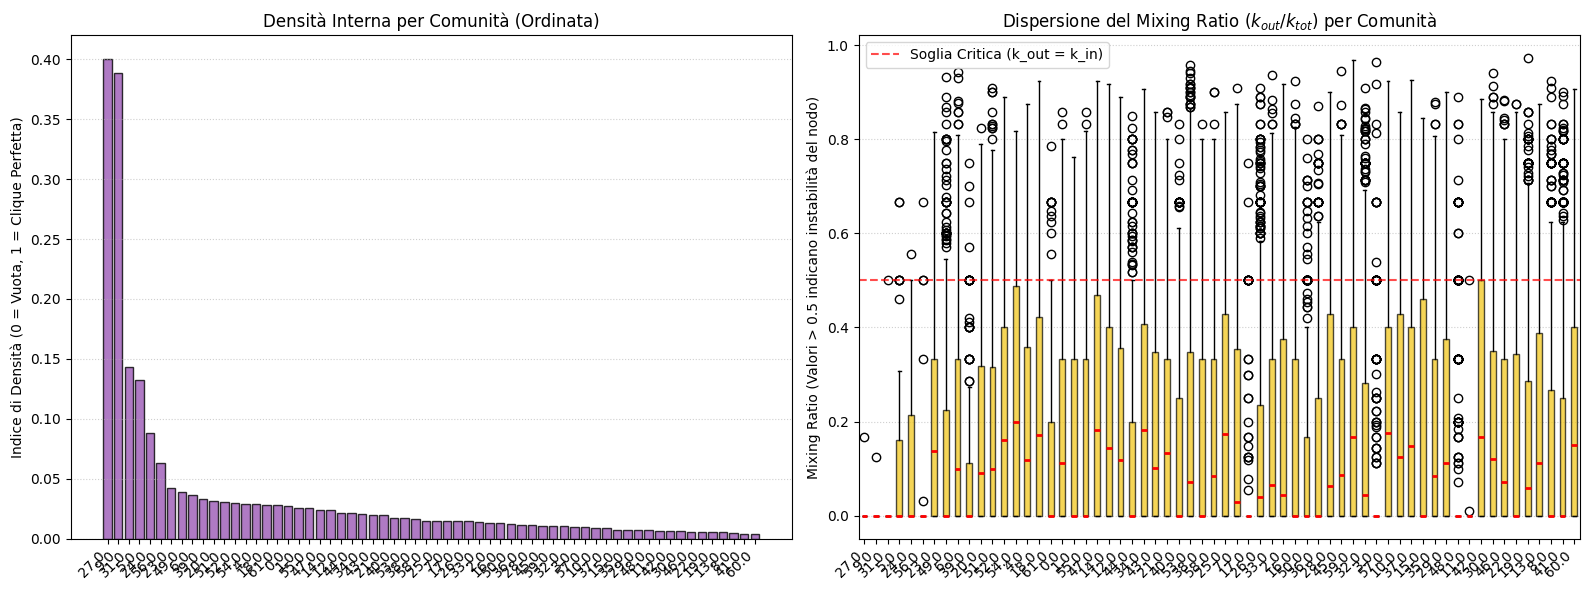

In [ ]:
if not df.empty:
    # 1. Calcolo delle metriche di coesione per ogni comunità
    grouped = df.groupby("Comunità")

    report_densita = []

    for com_name, com_data in grouped:
        N = len(com_data)
        somma_k_in = com_data["k_in"].sum()

        # Calcolo della densità interna (gestendo il caso di comunità con 1 solo nodo)
        if N > 1:
            densita_interna = somma_k_in / (N * (N - 1))
        else:
            densita_interna = 0.0  # Un solo nodo non può avere densità interna

        # Calcolo del Mixing Ratio medio per la comunità
        gradi_totali = com_data["k_in"] + com_data["k_out"]
        com_data = com_data.copy()
        com_data["mixing_ratio"] = np.where(
            gradi_totali > 0, com_data["k_out"] / gradi_totali, 0
        )

        mixing_medio = com_data["mixing_ratio"].mean()

        report_densita.append(
            {
                "Comunità": com_name,
                "Nodi": N,
                "Densità Interna": densita_interna,
                "Mixing Ratio Medio": mixing_medio,
            }
        )

    df_coesione = pd.DataFrame(report_densita).sort_values(
        by="Densità Interna", ascending=False
    )

    # 2. STAMPA DELLA TABELLA DI COESIONE
    print("=" * 85)
    print(
        f"{'COMUNITÀ':<25} | {'NODI':<8} | {'DENSITÀ INTERNA (0-1)':<22} | {'MIXING RATIO MEDIO':<20}"
    )
    print("-" * 85)
    for _, row in df_coesione.iterrows():
        print(
            f"{row['Comunità']:<25} | {int(row['Nodi']):<8} | {row['Densità Interna']:<22.4f} | {row['Mixing Ratio Medio']:<20.4f}"
        )
    print("=" * 85)
    print(
        "\n💡 NOTA SULLA DENSITÀ: Valori vicini a 1 indicano comunità quasi 'complete' (tutti collegati tra loro)."
    )
    print(
        "💡 NOTA SUL MIXING RATIO: Più è vicino a 0, più la comunità è isolata e protetta verso l'esterno.\n"
    )

    # 3. GENERAZIONE DEL GRAFICO COMPRENSIVO
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Grafico 1: Barre della Densità Interna
    bars = ax1.bar(
        df_coesione["Comunità"],
        df_coesione["Densità Interna"],
        color="#9b59b6",
        edgecolor="black",
        alpha=0.8,
    )
    ax1.set_title("Densità Interna per Comunità (Ordinata)", fontsize=12)
    ax1.set_ylabel("Indice di Densità (0 = Vuota, 1 = Clique Perfetta)")
    ax1.set_xticklabels(df_coesione["Comunità"], rotation=45, ha="right")
    ax1.grid(axis="y", linestyle=":", alpha=0.6)

    # Grafico 2: Boxplot del Mixing Ratio
    df["mixing_ratio"] = np.where(
        (df["k_in"] + df["k_out"]) > 0,
        df["k_out"] / (df["k_in"] + df["k_out"]),
        0,
    )

    data_to_plot = [
        df[df["Comunità"] == com]["mixing_ratio"].values
        for com in df_coesione["Comunità"]
    ]

    ax2.boxplot(
        data_to_plot,
        labels=df_coesione["Comunità"],
        patch_artist=True,
        boxprops=dict(facecolor="#f1c40f", color="black", alpha=0.7),
        medianprops=dict(color="red", linewidth=2),
    )

    ax2.set_title(
        "Dispersione del Mixing Ratio ($k_{out} / k_{tot}$) per Comunità",
        fontsize=12,
    )
    ax2.set_ylabel("Mixing Ratio (Valori > 0.5 indicano instabilità del nodo)")
    ax2.set_xticklabels(df_coesione["Comunità"], rotation=45, ha="right")
    ax2.axhline(
        y=0.5,
        color="r",
        linestyle="--",
        alpha=0.7,
        label="Soglia Critica (k_out = k_in)",
    )
    ax2.legend()
    ax2.grid(axis="y", linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Nessun dato disponibile per l'analisi di coesione.")

# Analisi dei Post

Totale post caricati: 192822
--------------------------------------------------


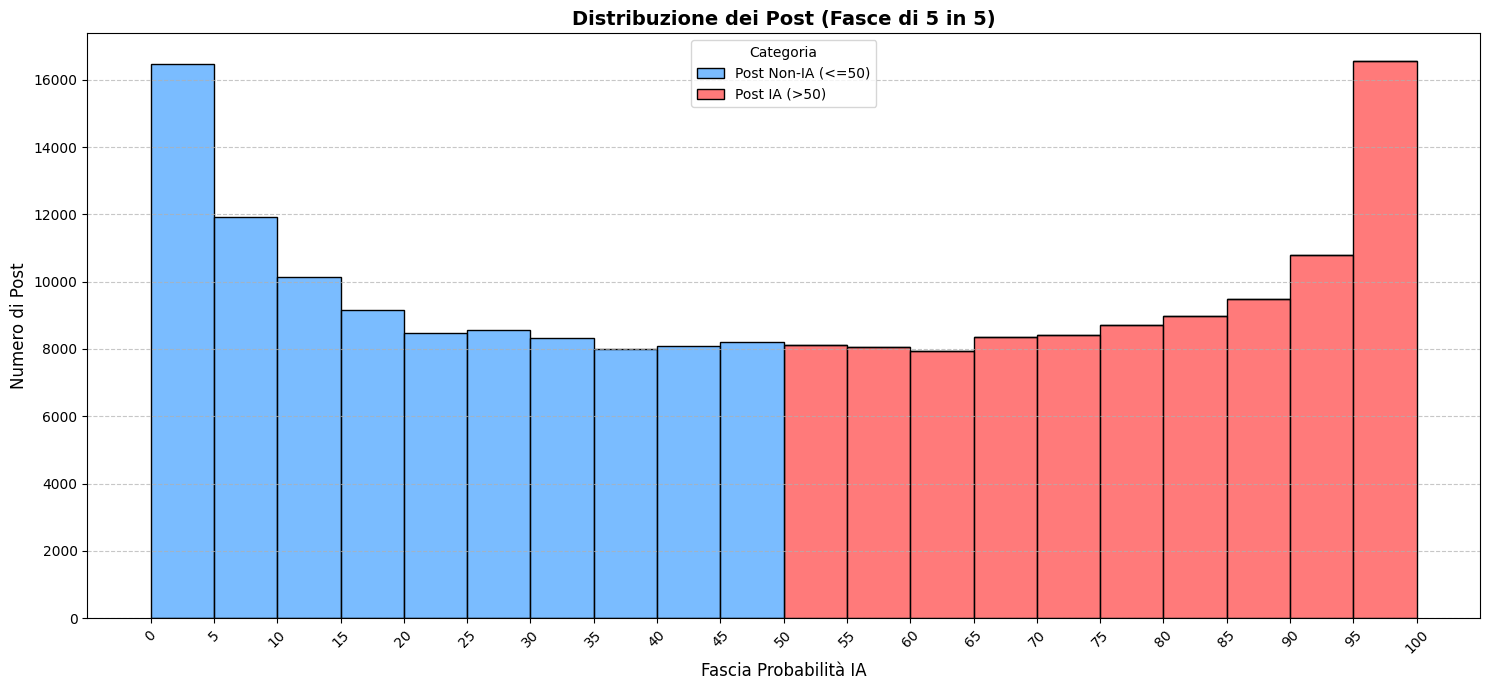

Conteggio post per singola fascia:
fascia_5
(-0.001, 5.0]    16474
(5.0, 10.0]      11920
(10.0, 15.0]     10149
(15.0, 20.0]      9167
(20.0, 25.0]      8487
(25.0, 30.0]      8574
(30.0, 35.0]      8340
(35.0, 40.0]      8000
(40.0, 45.0]      8097
(45.0, 50.0]      8205
(50.0, 55.0]      8117
(55.0, 60.0]      8057
(60.0, 65.0]      7946
(65.0, 70.0]      8366
(70.0, 75.0]      8415
(75.0, 80.0]      8701
(80.0, 85.0]      8971
(85.0, 90.0]      9498
(90.0, 95.0]     10788
(95.0, 100.0]    16550
Name: count, dtype: int64
--------------------------------------------------
STATISTICHE LUNGHEZZA TESTI IA (>50):
Numero di post IA analizzati: 95409
Lunghezza Media:   282.6 caratteri
Lunghezza Mediana: 233.0 caratteri
Lunghezza Minima:  1 caratteri
Lunghezza Massima: 28571 caratteri


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Caricamento del file CSV
file = "/content/sample_data/risultati.csv"
df = pd.read_csv(file)

# Assicuriamoci che ai_probability sia numerica e text sia una stringa
df['ai_probability'] = pd.to_numeric(df['ai_probability'], errors='coerce')
df['text'] = df['text'].astype(str)
df = df.dropna(subset=['ai_probability', 'text'])

# Se la tua colonna è su scala 0-1 (es. 0.5), la moltiplichiamo per 100
# per portarla sulla scala 0-100 che desideri visualizzare
if df['ai_probability'].max() <= 1.0:
    df['ai_probability'] = df['ai_probability'] * 100

print(f"Totale post caricati: {len(df)}")
print("-" * 50)

# ==========================================
# ISTOGRAMMA CON SCALA DA 5 A 5 (0, 5, 10, 15...)
# ==========================================
plt.figure(figsize=(15, 7))

# Soglia a 50 per dividere IA da Non-IA
df['Categoria'] = df['ai_probability'].apply(lambda x: 'Post IA (>50)' if x > 50 else 'Post Non-IA (<=50)')

# Generiamo i limiti dei blocchi ogni 5 unità: [0, 5, 10, 15, ..., 100]
passo_5 = list(range(0, 101, 5))

# Disegniamo l'istogramma
sns.histplot(
    data=df,
    x='ai_probability',
    hue='Categoria',
    bins=passo_5,
    multiple='stack',
    palette={'Post IA (>50)': '#ff4d4d', 'Post Non-IA (<=50)': '#4da6ff'},
    edgecolor='black'
)

plt.title('Distribuzione dei Post (Fasce di 5 in 5)', fontsize=14, fontweight='bold')
# Asse X mostra esattamente i numeri 0, 5, 10, 15... fino a 100
plt.xticks(passo_5, labels=[str(x) for x in passo_5], rotation=45, fontsize=10)
plt.xlabel('Fascia Probabilità IA', fontsize=12)
plt.ylabel('Numero di Post', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Conteggio testuale
df['fascia_5'] = pd.cut(df['ai_probability'], bins=passo_5, include_lowest=True)
print("Conteggio post per singola fascia:")
print(df['fascia_5'].value_counts().sort_index())
print("-" * 50)


# ==========================================
# ANALISI LUNGHEZZA TESTI IA > 50
# ==========================================
df_ia = df[df['ai_probability'] > 50].copy()
df_ia['lunghezza_caratteri'] = df_ia['text'].apply(len)

print("STATISTICHE LUNGHEZZA TESTI IA (>50):")
print(f"Numero di post IA analizzati: {len(df_ia)}")
print(f"Lunghezza Media:   {df_ia['lunghezza_caratteri'].mean():.1f} caratteri")
print(f"Lunghezza Mediana: {df_ia['lunghezza_caratteri'].median():.1f} caratteri")
print(f"Lunghezza Minima:  {df_ia['lunghezza_caratteri'].min()} caratteri")
print(f"Lunghezza Massima: {df_ia['lunghezza_caratteri'].max()} caratteri")

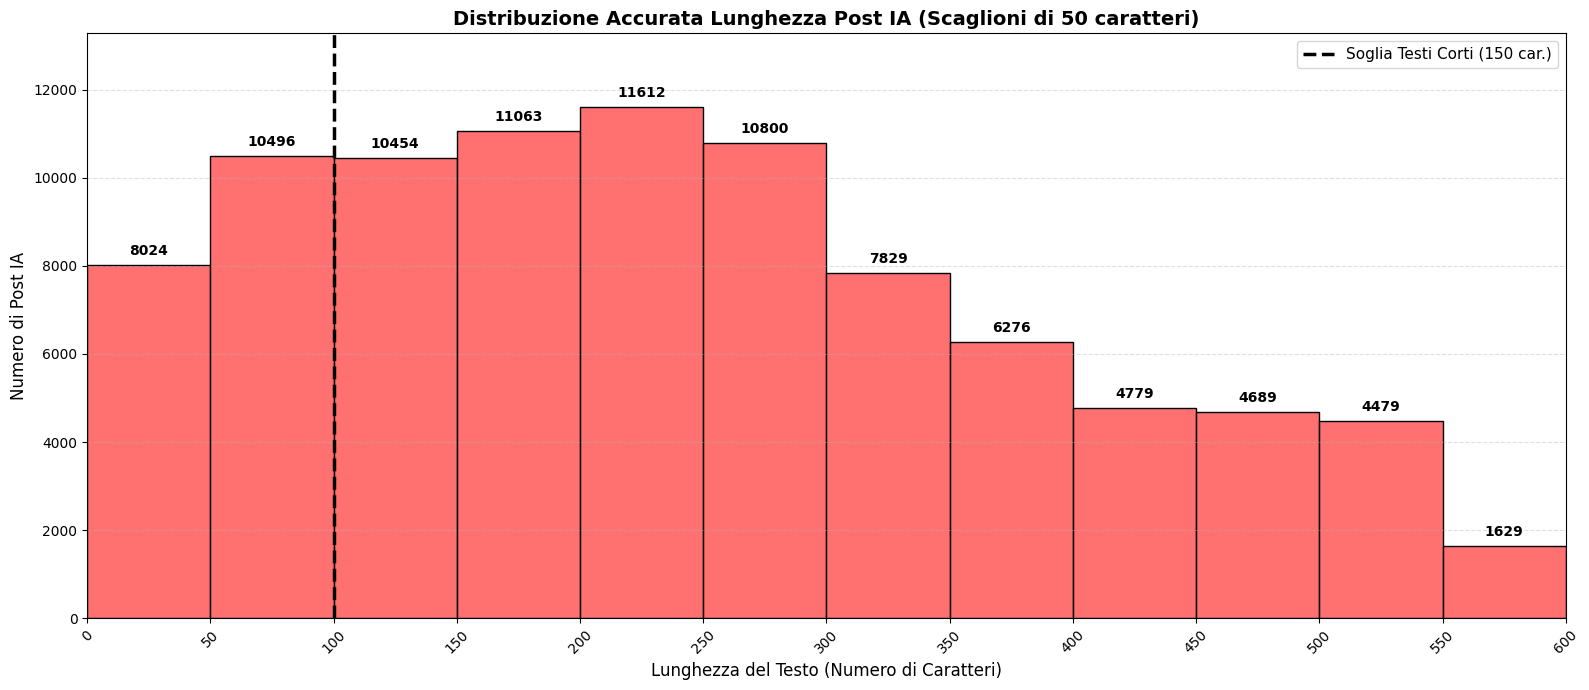

In [ ]:
# ==========================================
# ANALISI 3: Dimensionalità Post IA a scaglioni di 50 caratteri
# ==========================================
# 1. Isoliamo solo i post considerati generati da IA (> 50)
df_ia = df[df['ai_probability'] > 50].copy()

# 2. Calcoliamo la lunghezza in caratteri
df_ia['lunghezza_caratteri'] = df_ia['text'].apply(len)

# 3. Definiamo i blocchi (bin) di 50 in 50 caratteri
max_caratteri = int(df_ia['lunghezza_caratteri'].quantile(0.95))
limite_superiore = ((max_caratteri // 50) + 1) * 50

# Creiamo la lista dei passi: [0, 50, 100, 150, 200...]
blocchi_50 = list(range(0, max(limite_superiore + 1, 401), 50))

# 4. Creazione del Grafico
plt.figure(figsize=(16, 7))

# Memorizziamo il grafico in una variabile per poter accedere alle barre (patches)
ax = sns.histplot(
    data=df_ia,
    x='lunghezza_caratteri',
    bins=blocchi_50,
    color='#ff4d4d',
    edgecolor='black',
    alpha=0.8
)

# --- NUOVO: Aggiungiamo i valori numerici sopra ogni barra ---
for p in ax.patches:
    altezza = p.get_height()
    if altezza > 0: # Scrivi il numero solo se la barra non è vuota
        ax.annotate(
            f'{int(altezza)}',
            (p.get_x() + p.get_width() / 2., altezza),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )

# Linea verticale di riferimento sui 150 caratteri (limite testi corti)
plt.axvline(x=100, color='black', linestyle='--', linewidth=2.5, label='Soglia Testi Corti (150 car.)')

# Asse X mostra esattamente 0, 50, 100, 150...
plt.xticks(blocchi_50, labels=[str(x) for x in blocchi_50], rotation=45, fontsize=10)

plt.title('Distribuzione Accurata Lunghezza Post IA (Scaglioni di 50 caratteri)', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza del Testo (Numero di Caratteri)', fontsize=12)
plt.ylabel('Numero di Post IA', fontsize=12)
plt.xlim(0, blocchi_50[-1])

# Alziamo leggermente il limite superiore dell'asse Y per non far sovrapporre i numeri al bordo del grafico
plt.ylim(0, df_ia['lunghezza_caratteri'].value_counts(bins=blocchi_50).max() * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

Totale tag estratti dai post: 1168127
Tag unici trovati: 99700
--------------------------------------------------


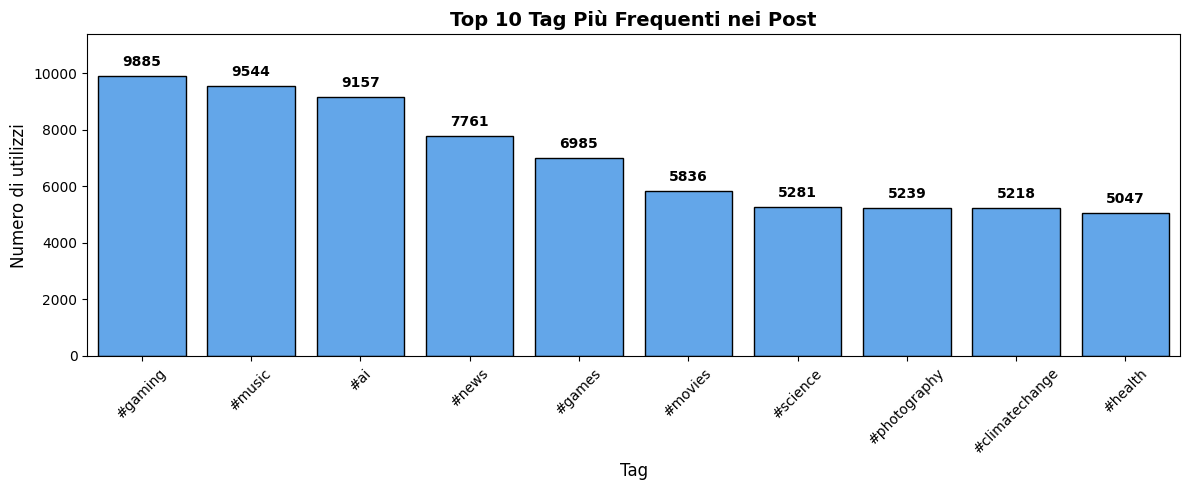

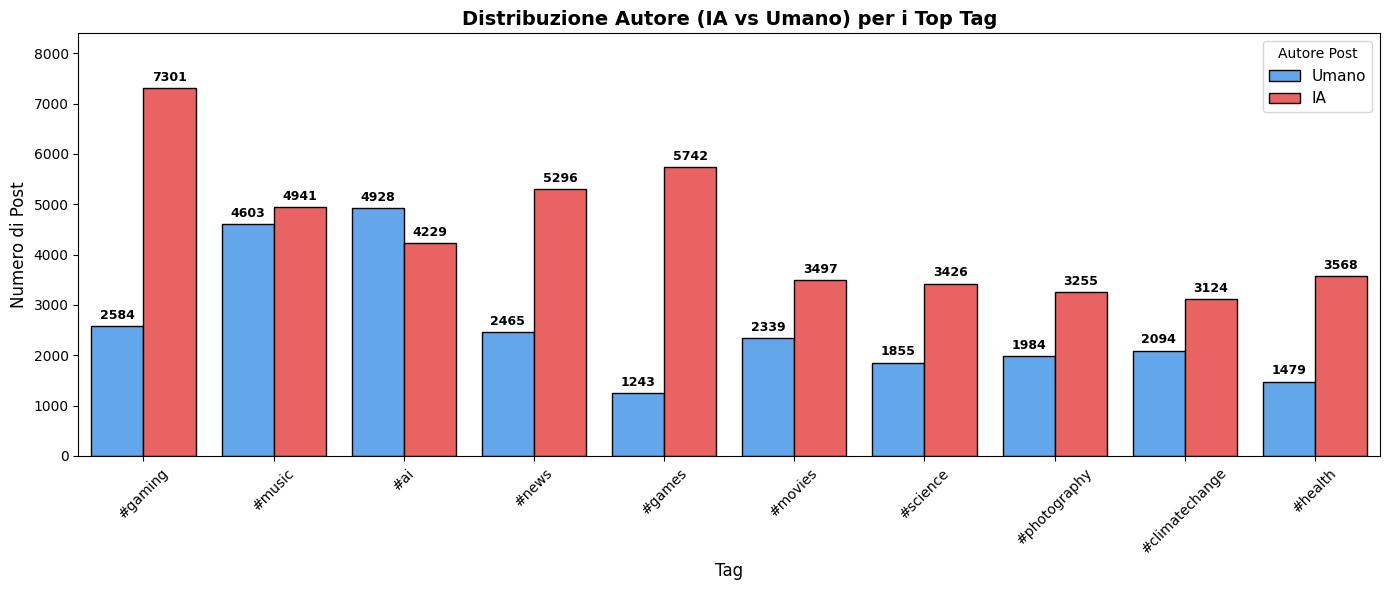

Tabella riassuntiva Tag e Autore:
Categoria         IA  Umano
tag                        
#gaming         7301   2584
#music          4941   4603
#ai             4229   4928
#news           5296   2465
#games          5742   1243
#movies         3497   2339
#science        3426   1855
#photography    3255   1984
#climatechange  3124   2094
#health         3568   1479


In [ ]:
# Pulizia dati
df['ai_probability'] = pd.to_numeric(df['ai_probability'], errors='coerce')
df['text'] = df['text'].astype(str)
df = df.dropna(subset=['ai_probability', 'text'])

# Normalizziamo la scala IA a 0-100 se è in decimali
if df['ai_probability'].max() <= 1.0:
    df['ai_probability'] = df['ai_probability'] * 100

# Classifichiamo i post in IA vs Umano
df['Categoria'] = df['ai_probability'].apply(lambda x: 'IA' if x > 50 else 'Umano')

# ==========================================
# ESTRAZIONE DEI TAG CON SPAZIO (es. # parola)
# ==========================================
righe_tag = []

for idx, row in df.iterrows():
    # Cerca il simbolo # seguito da eventuali spazi (\s*) e poi dalla parola (\w+)
    # re.findall restituirà solo la parola dentro le parentesi tonde
    parole_tag = re.findall(r'#\s*(\w+)', row['text'].lower())

    # Se il post contiene tag, ricostruiamo la stringa con il '#' attaccato per il grafico
    for parola in parole_tag:
        tag_pulito = f"#{parola}"
        righe_tag.append({'tag': tag_pulito, 'Categoria': row['Categoria']})

# Creiamo un nuovo DataFrame dedicato esclusivamente ai tag trovati
df_tags = pd.DataFrame(righe_tag)

if df_tags.empty:
    print("Attenzione: Non è stato trovato nessun tag preceduto da # nei testi dei post.")
else:
    print(f"Totale tag estratti dai post: {len(df_tags)}")
    print(f"Tag unici trovati: {df_tags['tag'].nunique()}")
    print("-" * 50)

    # Consideriamo i top 10 tag più frequenti per mantenere i grafici puliti e leggibili
    top_tags = df_tags['tag'].value_counts().nlargest(10).index
    df_top_tags = df_tags[df_tags['tag'].isin(top_tags)]

    # ==========================================
    # GRAFICO 1: Distribuzione Generale dei Top Tag
    # ==========================================
    plt.figure(figsize=(12, 5))
    ax1 = sns.countplot(
        data=df_top_tags,
        x='tag',
        order=top_tags,
        color='#4da6ff',
        edgecolor='black'
    )

    # Aggiungiamo i numeri sopra le barre del primo grafico
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')

    plt.title('Top 10 Tag Più Frequenti nei Post', fontsize=14, fontweight='bold')
    plt.xlabel('Tag', fontsize=12)
    plt.ylabel('Numero di utilizzi', fontsize=12)
    plt.xticks(rotation=45)

    # Alziamo il tetto dell'asse Y per evitare sovrapposizioni con i numeri
    plt.ylim(0, df_top_tags['tag'].value_counts().max() * 1.15)

    plt.tight_layout()
    plt.show()

    # ==========================================
    # GRAFICO 2: Distribuzione IA vs Umano per ogni Tag
    # ==========================================
    plt.figure(figsize=(14, 6))

    # Creiamo l'istogramma raggruppato (side-by-side)
    ax2 = sns.countplot(
        data=df_top_tags,
        x='tag',
        hue='Categoria',
        order=top_tags,
        palette={'IA': '#ff4d4d', 'Umano': '#4da6ff'},
        edgecolor='black'
    )

    # Aggiungiamo i numeri sopra ogni barra sdoppiata
    for p in ax2.patches:
        altezza = p.get_height()
        if altezza > 0: # Evita di scrivere "0" se una categoria non ha quel tag
            ax2.annotate(f'{int(altezza)}', (p.get_x() + p.get_width() / 2., altezza),
                        ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')

    plt.title('Distribuzione Autore (IA vs Umano) per i Top Tag', fontsize=14, fontweight='bold')
    plt.xlabel('Tag', fontsize=12)
    plt.ylabel('Numero di Post', fontsize=12)
    plt.xticks(rotation=45)

    # Calcolo dinamico dell'altezza massima per la scala Y
    conteggi_incrociati = pd.crosstab(df_top_tags['tag'], df_top_tags['Categoria'])
    plt.ylim(0, conteggi_incrociati.max().max() * 1.15)

    plt.legend(title='Autore Post', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Mostriamo anche un riepilogo testuale al terminale
    print("Tabella riassuntiva Tag e Autore:")
    tabella_riepilogo = pd.crosstab(df_top_tags['tag'], df_top_tags['Categoria'])
    print(tabella_riepilogo.loc[top_tags])

In [ ]:
# Post IA corti: lunghezza strettamente inferiore a 150 caratteri
post_corti = len(df_ia[df_ia['lunghezza_caratteri'] < 100])

# Post IA lunghi: lunghezza maggiore o uguale a 150 caratteri
post_lunghi = len(df_ia[df_ia['lunghezza_caratteri'] >= 100])

print("RIASSUNTO DIMENSIONALITÀ POST IA:")
print("-" * 35)
print(f"Post Corti (< 100 caratteri):  {post_corti}")
print(f"Post Lunghi (>= 100 caratteri): {post_lunghi}")
print("-" * 35)
print(f"Totale Post IA verificati:     {post_corti + post_lunghi}")

RIASSUNTO DIMENSIONALITÀ POST IA:
-----------------------------------
Post Corti (< 100 caratteri):  18520
Post Lunghi (>= 100 caratteri): 76889
-----------------------------------
Totale Post IA verificati:     95409


--- RISULTATI FILTRAGGIO (Checkworthy Score > 80%) ---
Totale post che superano la soglia: 34721
  - Di cui Umani: 17317
  - Di cui IA:    17404
-------------------------------------------------------


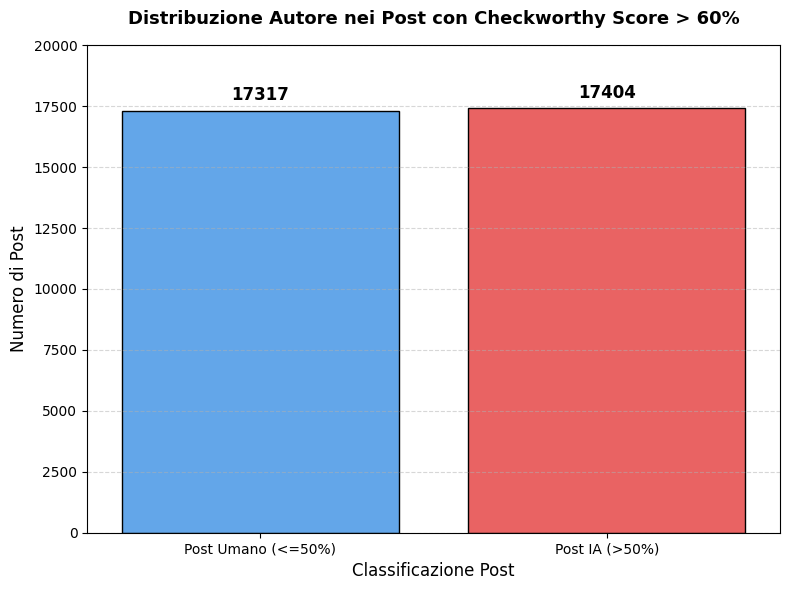

In [ ]:
# 1. Caricamento del file CSV
# Sostituisci 'il_tuo_file.csv' con il percorso reale del tuo file
file = "/content/sample_data/post_verificare_validita.csv"
df = pd.read_csv(file)

# Pulizia e conversione dei dati per evitare errori
df['ai_probability'] = pd.to_numeric(df['ai_probability'], errors='coerce')
df['checkworthy_score'] = pd.to_numeric(df['checkworthy_score'], errors='coerce')
df['text'] = df['text'].astype(str)
df = df.dropna(subset=['ai_probability', 'checkworthy_score', 'text'])

# 2. Normalizzazione delle scale (0-1 oppure 0-100)
# Se lo score nel CSV è da 0 a 1 (es. 0.75), lo portiamo a scala 100
if df['checkworthy_score'].max() <= 1.0:
    df['checkworthy_score'] = df['checkworthy_score'] * 100

# Facciamo lo stesso per la probabilità IA
if df['ai_probability'].max() <= 1.0:
    df['ai_probability'] = df['ai_probability'] * 100

# 3. Filtraggio: solo i testi con checkworthy_score > 60%
df_filtrato = df[df['checkworthy_score'] > 80].copy()

# 4. Classificazione in IA vs Umano (soglia 50%)
df_filtrato['Tipo_Autore'] = df_filtrato['ai_probability'].apply(
    lambda x: 'Post IA (>50%)' if x > 50 else 'Post Umano (<=50%)'
)

# Conteggio numerico da stampare nel terminale
conteggi = df_filtrato['Tipo_Autore'].value_counts()
totale_filtrati = len(df_filtrato)

print(f"--- RISULTATI FILTRAGGIO (Checkworthy Score > 80%) ---")
print(f"Totale post che superano la soglia: {totale_filtrati}")
print(f"  - Di cui Umani: {conteggi.get('Post Umano (<=50%)', 0)}")
print(f"  - Di cui IA:    {conteggi.get('Post IA (>50%)', 0)}")
print("-" * 55)

# ==========================================
# CREAZIONE DEL GRAFICO A ISTOGRAMMA
# ==========================================
plt.figure(figsize=(8, 6))

# Usiamo un countplot per vedere la frequenza delle due categorie
ax = sns.countplot(
    data=df_filtrato,
    x='Tipo_Autore',
    hue='Tipo_Autore',  # Colorazione differenziata
    palette={'Post IA (>50%)': '#ff4d4d', 'Post Umano (<=50%)': '#4da6ff'},
    edgecolor='black',
    legend=False
)

# Aggiungiamo il valore numerico preciso sopra ogni barra
for p in ax.patches:
    altezza = p.get_height()
    if altezza > 0:
        ax.annotate(
            f'{int(altezza)}',
            (p.get_x() + p.get_width() / 2., altezza),
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )

# Personalizzazione del grafico
plt.title('Distribuzione Autore nei Post con Checkworthy Score > 60%', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Classificazione Post', fontsize=12)
plt.ylabel('Numero di Post', fontsize=12)

# Alziamo il tetto dell'asse Y per lasciare spazio ai numeri sopra le barre
plt.ylim(0, max(conteggi.values) * 1.15 if len(conteggi) > 0 else 10)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Analisi sui post Fake e post Veritieri

/tmp/ipykernel_1117/1907059501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_1117/1907059501.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


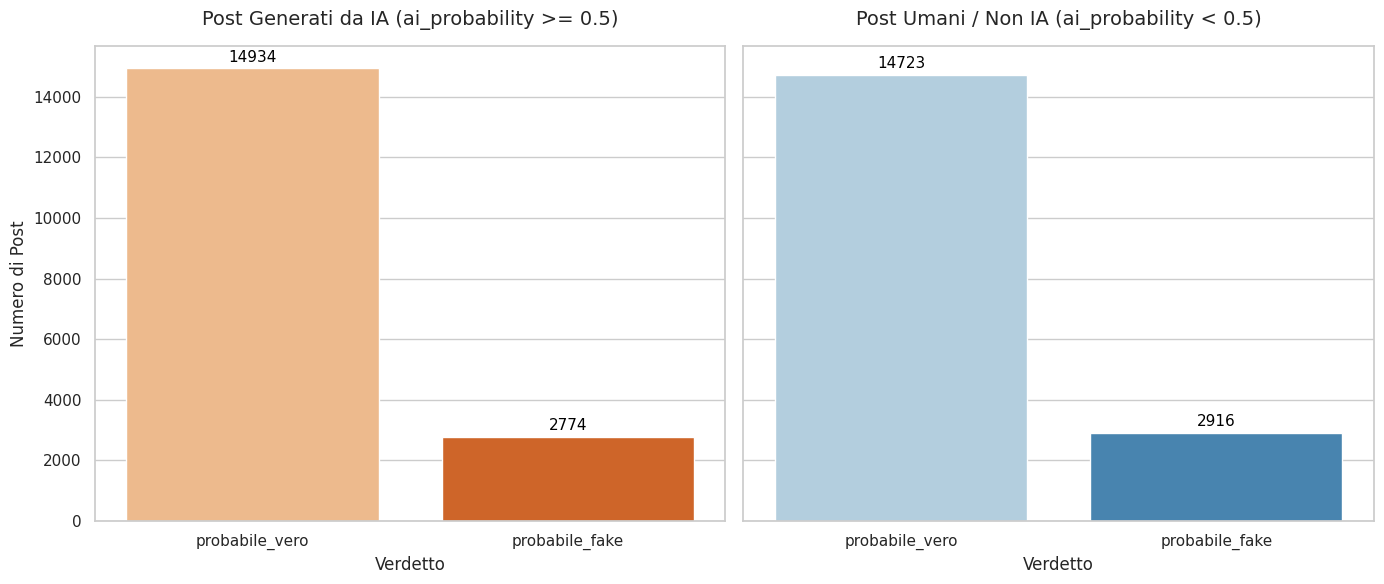

In [2]:
# 1. Carica il tuo file CSV (sostituisci 'il_tuo_file.csv' con il nome reale del file)
file="/content/sample_data/post_verificati.csv"
df = pd.read_csv(file)

# Pulizia minima: uniformiamo il testo della colonna 'verdetto' (es. tutto minuscolo)
# per evitare che 'Fake' e 'fake' vengano contati come cose diverse
df['verdetto'] = df['verdetto'].astype(str).str.lower().str.strip()

# 2. Dividiamo il dataset in base alla probabilità che sia AI
# Assumiamo che ai_probability > 0.5 indichi un post generato da IA
soglia_ai = 0.5
df_ia = df[df['ai_probability'] >= soglia_ai]
df_non_ia = df[df['ai_probability'] < soglia_ai]

# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 3. Primo Istogramma/Grafico a barre: POST IA
sns.countplot(
    data=df_ia,
    x='verdetto',
    ax=axes[0],
    palette='Oranges',
    order=df_ia['verdetto'].value_counts().index
)
axes[0].set_title(f'Post Generati da IA (ai_probability >= {soglia_ai})', fontsize=14, pad=15)
axes[0].set_xlabel('Verdetto', fontsize=12)
axes[0].set_ylabel('Numero di Post', fontsize=12)

# Aggiunge i valori sopra le barre
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

# 4. Secondo Istogramma/Grafico a barre: POST NON IA
sns.countplot(
    data=df_non_ia,
    x='verdetto',
    ax=axes[1],
    palette='Blues',
    order=df_non_ia['verdetto'].value_counts().index
)
axes[1].set_title(f'Post Umani / Non IA (ai_probability < {soglia_ai})', fontsize=14, pad=15)
axes[1].set_xlabel('Verdetto', fontsize=12)
axes[1].set_ylabel('', fontsize=12) # Condividono l'asse Y, quindi lo lasciamo vuoto a destra

# Aggiunge i valori sopra le barre
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

# Ottimizza lo spazio e mostra il grafico
plt.tight_layout()
plt.show()